In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image, ImageEnhance
#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [2]:
train_dir= "C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Training"
test_dir= "C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing"

#load and shuffle train data
train_paths = []
train_labels = []

#for training
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir,label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels) #prevent overfitting

#for testing
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir,label)):
        test_paths.append(os.path.join(os.path.join(test_dir,label,image)))
        test_labels.append(label)
test_paths

['C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_1.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_10.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_100.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_101.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_102.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_103.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_104.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_105.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_106.jpg',
 'C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\glioma\\Te-gl_107.jpg',
 'C

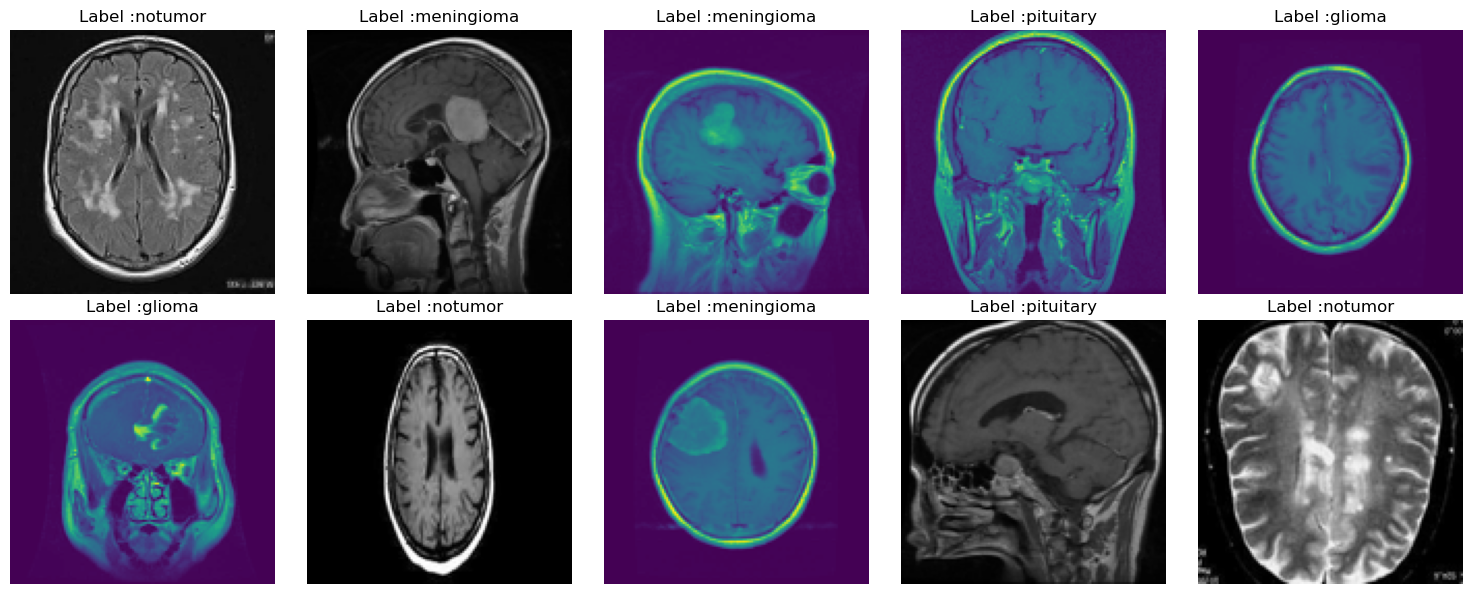

In [3]:
#displaying images
random_indices = random.sample(range(len(train_paths)),10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128,128))

    #displaying images 
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label :{train_labels[idx]}")
plt.tight_layout()
plt.show()

In [4]:
#Image augmentation
def augment_image(image):
    image = np.array(image)
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image
    
#Load images and apply augmentation (0,255)
def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        img = augment_image(img)
        images.append(img)
    return np.array(images)
        
def encoder(labels): #encoder labels converting integer names to integer
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)
    
#data generator for batching
def data_generator(paths, labels, batch_size=12):
    while True:
            for i in range(0, len(paths), batch_size):
                batch_paths = paths[i:i + batch_size]
                batch_labels = labels[i:i + batch_size]
                batch_images = open_images(batch_paths)         
                batch_labels = encoder(batch_labels)           
    
                yield batch_images, batch_labels

    

In [5]:
# Model Architecture (128,128,3)
import math
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top= False, weights='imagenet')

#freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set only the last few layers 
base_model.layers[-2].trainable = True 
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

#Build Model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(base_model) 
model.add(Flatten()) 
model.add(Dropout(0.3)) 

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2)) 

model.add(Dense(len(os.listdir(train_dir)),activation='softmax')) 

#compile model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

#Parameters
batch_size = 20
steps = math.ceil(len(train_paths) / batch_size)
epochs = 5

history = model.fit(
    data_generator(train_paths, train_labels, batch_size=batch_size),
    epochs=epochs,
    steps_per_epoch=steps
)
model.save('model.h5')

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 156s 548ms/step - loss: 0.4569 - sparse_categorical_accuracy: 0.8250
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 8324s 30s/step - loss: 0.2369 - sparse_categorical_accuracy: 0.9125
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 162s 580ms/step - loss: 0.1598 - sparse_categorical_accuracy: 0.9396
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 167s 598ms/step - loss: 0.1129 - sparse_categorical_accuracy: 0.9582
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 200s 713ms/step - loss: 0.0804 - sparse_categorical_accuracy: 0.9718


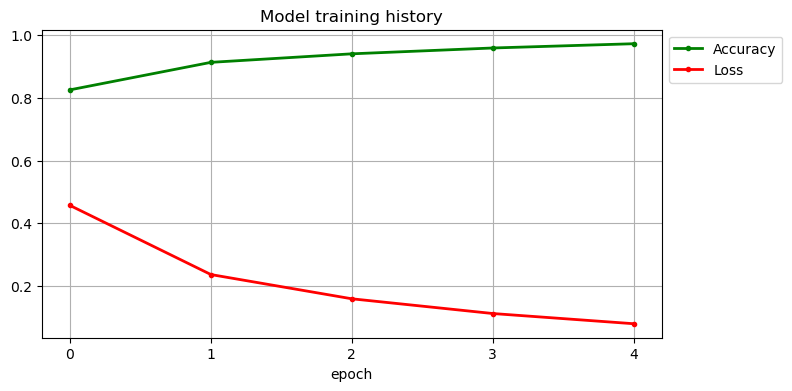

In [6]:
#plotting losses
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2)
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Model training history')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'],loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encoder(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))



50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 895ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       400
           1       0.90      0.78      0.83       400
           2       0.91      1.00      0.95       400
           3       0.97      0.97      0.97       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



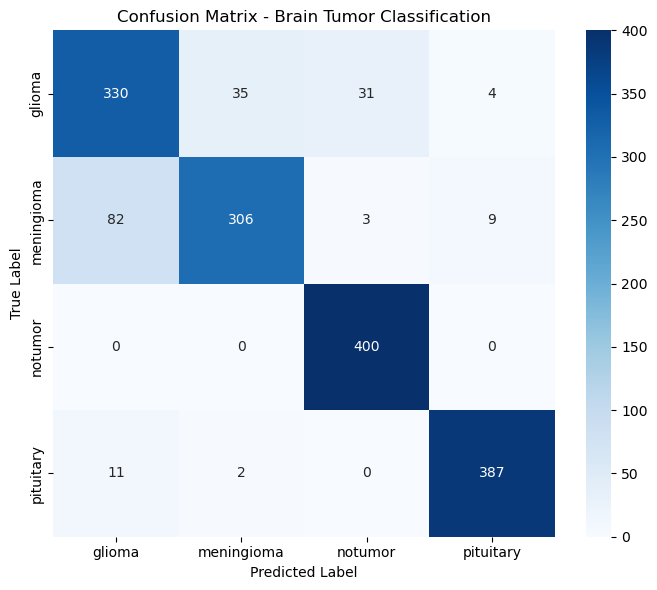

In [14]:
#confusion matrix
y_pred_classes = np.argmax(test_predictions, axis=1)

cm = confusion_matrix(test_labels_encoded, y_pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)  
plt.show()

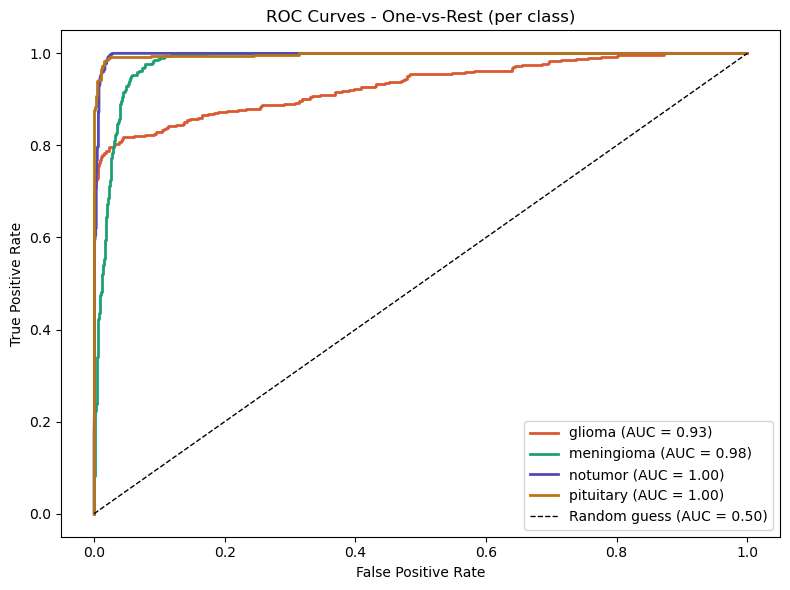

In [16]:
#ROC AUC curve
y_test_bin = label_binarize(test_labels_encoded, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
colors = ['#D85A30', '#1D9E75', '#534AB7', '#BA7517']

for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - One-vs-Rest (per class)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [8]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma','meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


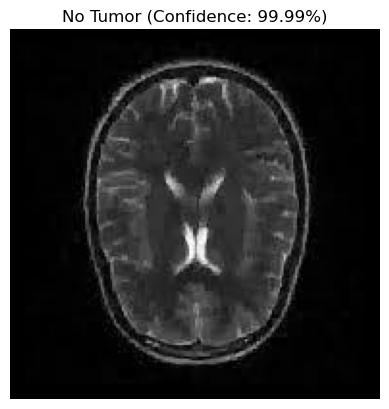

In [9]:
image_path = "C:\\Users\\saumi\\Desktop\\Cancer detection project\\MRI images\\Testing\\notumor\\Te-no_19.jpg"
detect_and_display(image_path,model)